In [25]:
import pandas as pd

df = pd.read_csv("spam_email_dataset.csv")

print(df.shape)
print(df.head())
print(df.isnull().sum())
print(df.duplicated().sum())
print(df['label'].value_counts())

(10000, 20)
   email_id           subject  \
0         0     Weekly Report   
1         1    Project Update   
2         2    🔥WIN BIG NOW!!   
3         3    🔥WIN BIG NOW!!   
4         4  Meeting Reminder   

                                          email_text  num_words  \
0  budget review - Statement our I claim world st...         19   
1  team sync - President series today already. In...         18   
2  win free urgent offer limited limited urgent u...         19   
3  guarantee click now cash offer click now guara...         16   
4  team sync - Significant property hotel not add...         18   

   num_characters  num_exclamation_marks  num_links  has_suspicious_link  \
0             114                      0          2                    0   
1             114                      0          7                    0   
2             126                      0          4                    1   
3             101                      0          7                    1   
4     

In [26]:
df = df.dropna()
df = df.drop_duplicates()

print(df.shape)

(10000, 20)


In [27]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

df['clean_text'] = df['email_text'].apply(clean_text)

In [28]:
from sklearn.model_selection import train_test_split

X = df['clean_text']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [29]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    stop_words='english',
    max_features=5000
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

In [30]:
from sklearn.naive_bayes import MultinomialNB

nb = MultinomialNB()

nb.fit(X_train_tfidf, y_train)

nb_pred = nb.predict(X_test_tfidf)

In [31]:
from sklearn.svm import LinearSVC

svm = LinearSVC()

svm.fit(X_train_tfidf, y_train)

svm_pred = svm.predict(X_test_tfidf)

In [32]:
from sklearn.metrics import accuracy_score, classification_report

print("NAIVE BAYES")
print("Accuracy:", accuracy_score(y_test, nb_pred))
print(classification_report(y_test, nb_pred))

print("\nSVM")
print("Accuracy:", accuracy_score(y_test, svm_pred))
print(classification_report(y_test, svm_pred))

NAIVE BAYES
Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1201
           1       1.00      1.00      1.00       799

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000


SVM
Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1201
           1       1.00      1.00      1.00       799

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



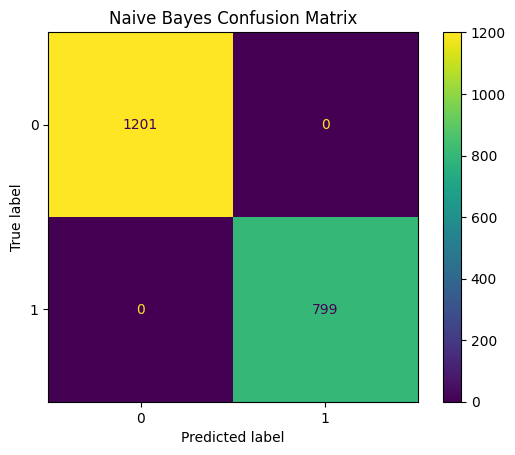

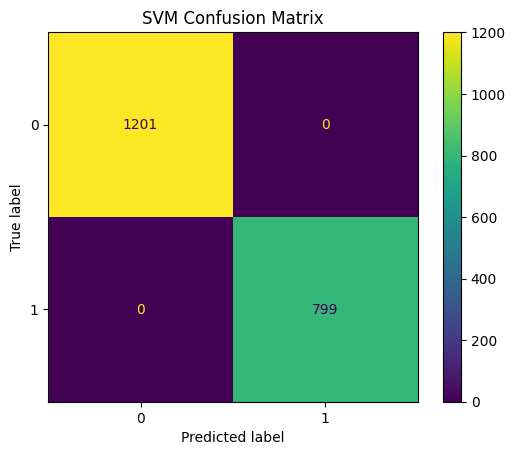

In [33]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(y_test, nb_pred)
plt.title("Naive Bayes Confusion Matrix")
plt.show()

ConfusionMatrixDisplay.from_predictions(y_test, svm_pred)
plt.title("SVM Confusion Matrix")
plt.show()